In [ ]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

#load data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleanup
df['job_posted_date'] =pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


# Filter for Vietnam Data Analyst roles

In [36]:
df_DA_VN =df[(df['job_country'] == 'Vietnam') & (df['job_title_short'] == 'Data Analyst')]

# Best locations for Data Analyst


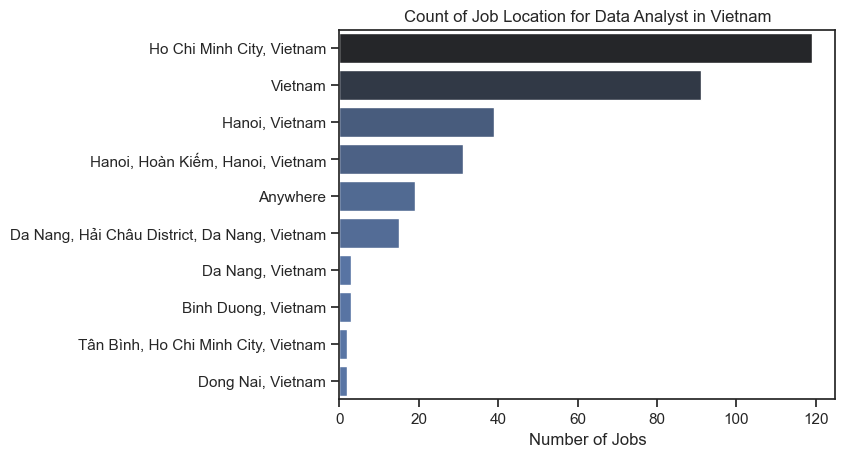

In [52]:
df_plot = df_DA_VN['job_location'].value_counts().head(10).to_frame()
# Using Seaborn
sns.set_theme(style='ticks')
sns.barplot(data=df_plot,x='count',y='job_location',hue='count',palette='dark:b_r',legend=False)
plt.title('Count of Job Location for Data Analyst in Vietnam')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

# Using matplotlib
# df_plot[::-1].plot(kind='barh') 

# Job Oppoturnities

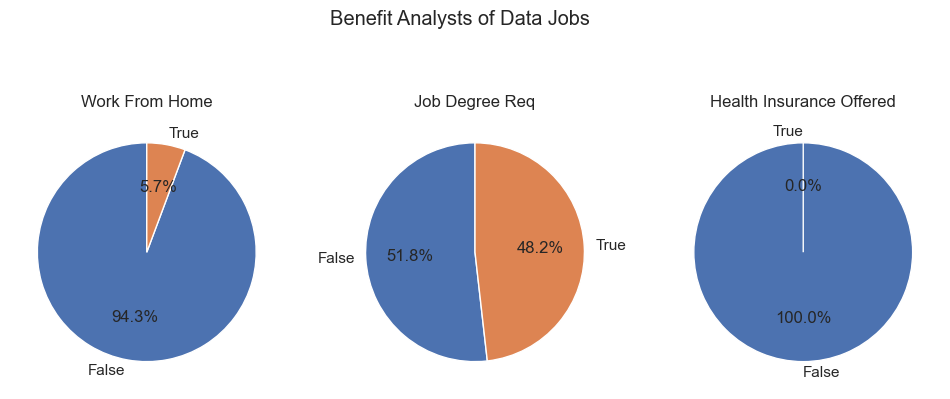

In [42]:
dict_column ={
    'job_work_from_home':'Work From Home',
    'job_no_degree_mention':'Job Degree Req',
    'job_health_insurance':'Health Insurance Offered' 
}

fig,ax =plt.subplots(1 ,3)
fig.set_size_inches((12,5))


for i,(column , title) in enumerate (dict_column.items()):
    ax[i].pie(df_DA_VN[column].value_counts().reindex([False,True],fill_value=0), # Make sure there's only 2 values True and False
              labels=['False','True'],
              startangle=90,
              autopct='%1.1f%%')
    ax[i].set_title(title)
plt.suptitle('Benefit Analysts of Data Jobs')
plt.show()



# Which company have the most number of jobs?

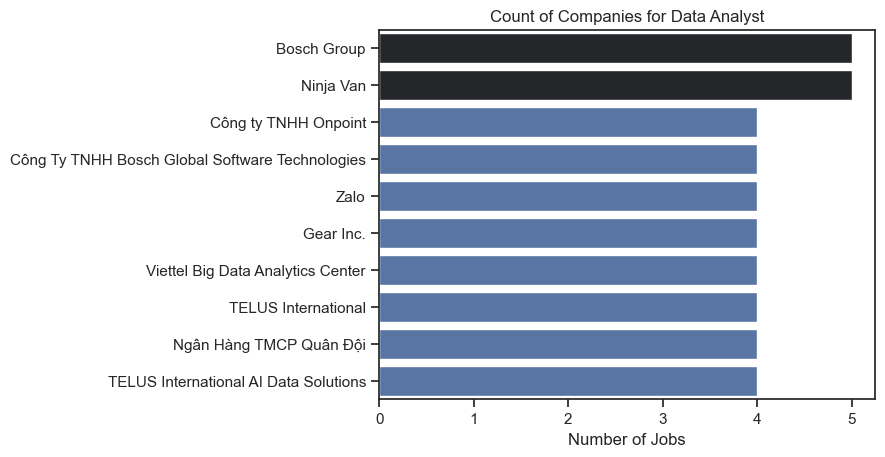

In [45]:
# Filter by company name
df_plot = df_DA_VN['company_name'].value_counts().head(10).to_frame()

# Using Seaborn
sns.set_theme(style='ticks')
sns.barplot(data=df_plot,x='count',y='company_name',hue='count',palette='dark:b_r',legend=False)
plt.title('Count of Companies for Data Analyst')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

# Using matplotlib
# df_plot[::-1].plot(kind='barh') 